/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Input past 3 days: [35 37 38]
Predicted tomorrow temperature: 38.3149


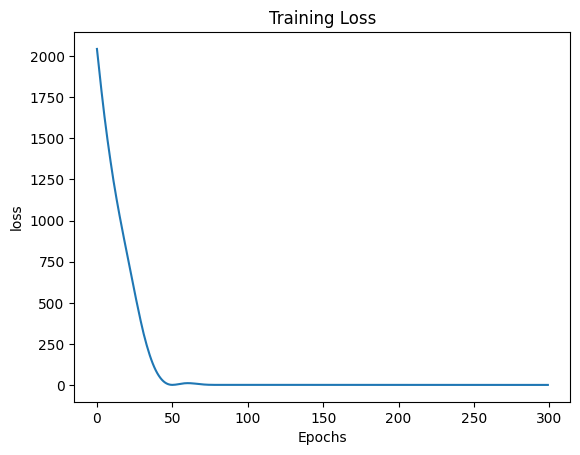

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. Create dataset
data = np.array([30, 32, 31, 33, 34, 36, 37, 35, 38, 40])

x = []
y = []

# 2. Convert data into sequential format (window of 3 days)
for i in range(len(data) - 3):
    x.append(data[i:i+3])
    y.append(data[i+3])

x = np.array(x)
y = np.array(y)

# 3. Reshape input to be [samples, time steps, features]
# SimpleRNN expects a 3D input shape
x = x.reshape((x.shape[0], x.shape[1], 1))

# 4. Build RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(3, 1)))
model.add(Dense(1))

# 5. Compile and Train
model.compile(optimizer='adam', loss='mse')
history = model.fit(x, y, epochs=300, verbose=0)

# 6. Provide test input sequence to predict next value
test_input = np.array([35, 37, 38])
test_input_reshaped = test_input.reshape((1, 3, 1))

prediction = model.predict(test_input_reshaped)

# Output results
print(f"Input past 3 days: {test_input}")
print(f"Predicted tomorrow temperature: {prediction[0][0]:.4f}")

# 7. Plot Training Loss
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.show()